<a href="https://colab.research.google.com/github/kiran-ingale/MIDS-repo/blob/main/MIDS_assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"

columns = [
    "Sex", "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight", "Rings"
]

df = pd.read_csv(url, header=None, names=columns)
df.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])


In [ ]:
X = df.drop("Rings", axis=1)
y = df["Rings"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


Mean Squared Error: 0.17632535256764686
Root Mean Squared Error: 0.41991112460572755
R² Score: 0.45894160329764655


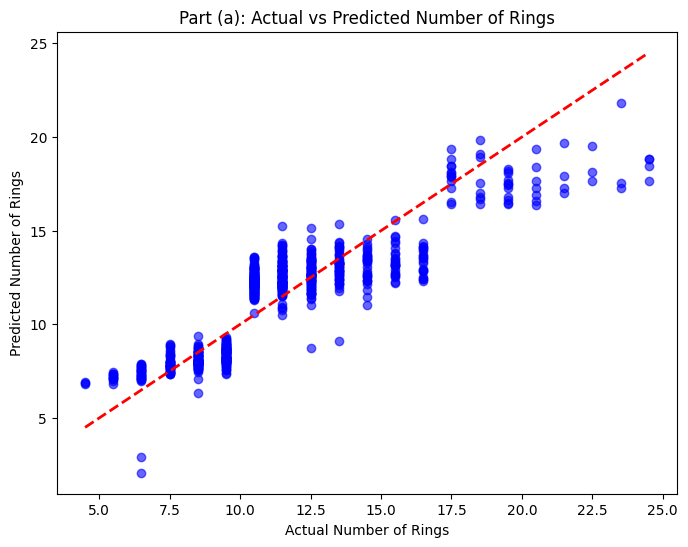

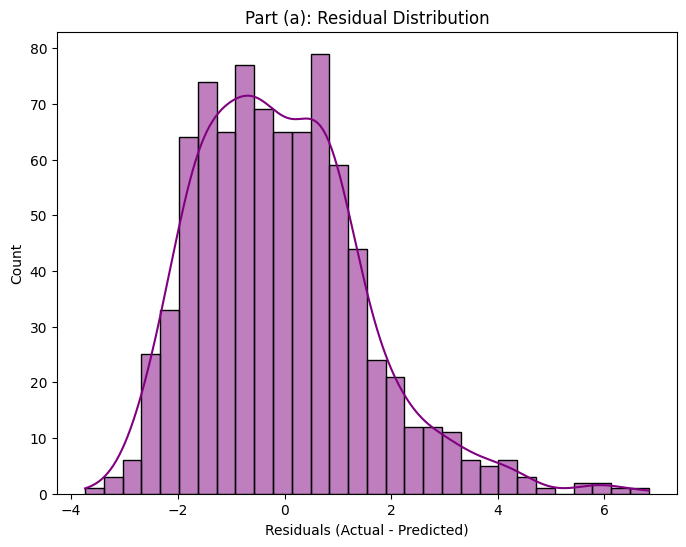

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Number of Rings")
plt.ylabel("Predicted Number of Rings")
plt.title("Part (a): Actual vs Predicted Number of Rings")
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Part (a): Residual Distribution")
plt.show()


In [ ]:
df["Age"] = df["Rings"] + 1.5
df.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Ring_Class,Age
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,1,16.5
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,8.5
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1,10.5
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,1,11.5
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0,8.5


In [ ]:
# Features: all physical measurements + Sex
X = df.drop(["Rings", "Age"], axis=1)
y = df["Age"]  # target is Age


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

age_model = LinearRegression()
age_model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = age_model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Squared Error (MSE): 2.4771517356225625
Root Mean Squared Error (RMSE): 1.573896990156142
R² Score: 0.7711682521449889


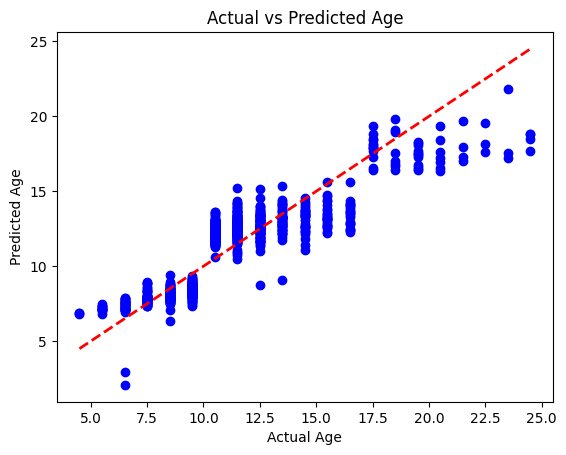

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")
plt.show()
